Name: **SREYA S**
Roll No: **B24CSB68**
Batch: **R5B**

In [ ]:
#CYCLE 1 DATA PREPROCESSING
#Q1
#Upload the DB
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

In [ ]:
#Load the database
df = pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
#Dataset Information
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
#Rows, Columns, Data Types and Missing Values
print("Rows and Columns:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Rows and Columns: (614, 13)

Data Types
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
#Display First, Last and Random Records
print("First Five Records")
display(df.head())

print("Last Five Records")
display(df.tail())

print("Random Five Records")
display(df.sample(5))

First Five Records


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Last Five Records


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


Random Five Records


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
165,LP001574,Male,Yes,0,Graduate,No,3707,3166.0,182.0,NaN,1.0,Rural,Y
390,LP002255,Male,No,3+,Graduate,No,9167,0.0,185.0,360.0,1.0,Rural,Y
287,LP001926,Male,Yes,0,Graduate,No,3704,2000.0,120.0,360.0,1.0,Rural,Y
202,LP001682,Male,Yes,3+,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N
404,LP002301,Female,No,0,Graduate,Yes,7441,0.0,194.0,360.0,1.0,Rural,N


In [ ]:
#Handle Missing Values
# Numerical Columns
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(), inplace=True)

# Categorical Columns
cat_cols = ["Gender","Married","Dependents",
            "Self_Employed","Credit_History"]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_1896/871317005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
/tmp/ipykernel_1896/871317005.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
#Remove Duplicate Records
print("Duplicate Records:",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:",df.shape)

Duplicate Records: 0
Shape after removing duplicates: (614, 13)


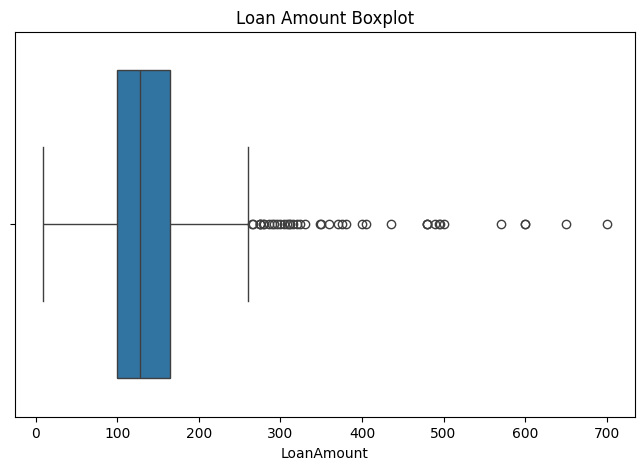

Lower Limit: 3.5
Upper Limit: 261.5


In [ ]:
#Detect Outliers using IQR and Visualize
plt.figure(figsize=(8,5))
sns.boxplot(x=df["LoanAmount"])
plt.title("Loan Amount Boxplot")
plt.show()

Q1=df["LoanAmount"].quantile(0.25)
Q3=df["LoanAmount"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

print("Lower Limit:",lower)
print("Upper Limit:",upper)

In [ ]:
#Handle Outliers
df=df[(df["LoanAmount"]>=lower) &
      (df["LoanAmount"]<=upper)]
print(df.shape)

(573, 13)


In [ ]:
#Label Encoding
label=LabelEncoder()

label_cols=["Gender",
            "Married",
            "Education",
            "Self_Employed",
            "Loan_Status"]

for col in label_cols:
    df[col]=label.fit_transform(df[col])

df["Dependents"]=df["Dependents"].replace("3+","3")
df["Dependents"]=df["Dependents"].astype(int)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,Urban,1


In [ ]:
#One-Hot Encoding
onehot=pd.get_dummies(df,columns=["Property_Area"])
onehot.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,True


In [ ]:
#Feature Scaling
#Min Max Scaling
minmax=MinMaxScaler()
cols=["ApplicantIncome",
      "CoapplicantIncome",
      "LoanAmount"]

df_minmax=df.copy()
df_minmax[cols]=minmax.fit_transform(df_minmax[cols])
df_minmax.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,0.146139,0.000000,0.474104,360.0,1.0,Urban,1
1,LP001003,1,1,1,0,0,0.113675,0.044567,0.474104,360.0,1.0,Rural,0
2,LP001005,1,1,0,0,1,0.073083,0.000000,0.227092,360.0,1.0,Urban,1
3,LP001006,1,1,0,1,0,0.062389,0.069687,0.442231,360.0,1.0,Urban,1
4,LP001008,1,0,0,0,0,0.150012,0.000000,0.525896,360.0,1.0,Urban,1


In [ ]:
#Standardization
standard=StandardScaler()
df_standard=df.copy()
df_standard[cols]=standard.fit_transform(df_standard[cols])
df_standard.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,0.328911,-0.630154,-0.010433,360.0,1.0,Urban,1
1,LP001003,1,1,1,0,0,-0.018351,0.012474,-0.010433,360.0,1.0,Rural,0
2,LP001005,1,1,0,0,1,-0.452565,-0.630154,-1.348463,360.0,1.0,Urban,1
3,LP001006,1,1,0,1,0,-0.566948,0.374698,-0.183082,360.0,1.0,Urban,1
4,LP001008,1,0,0,0,0,0.370330,-0.630154,0.270122,360.0,1.0,Urban,1


In [ ]:
#Feature Selection using Correlation
corr=df.corr(numeric_only=True)
corr["Loan_Status"].sort_values(ascending=False)

,Loan_Status
Loan_Status,1.000000
Credit_History,0.558304
Married,0.092127
Gender,0.020720
Dependents,0.011922
ApplicantIncome,0.011053
CoapplicantIncome,-0.005103
Self_Employed,-0.017901
Loan_Amount_Term,-0.018222
LoanAmount,-0.026691


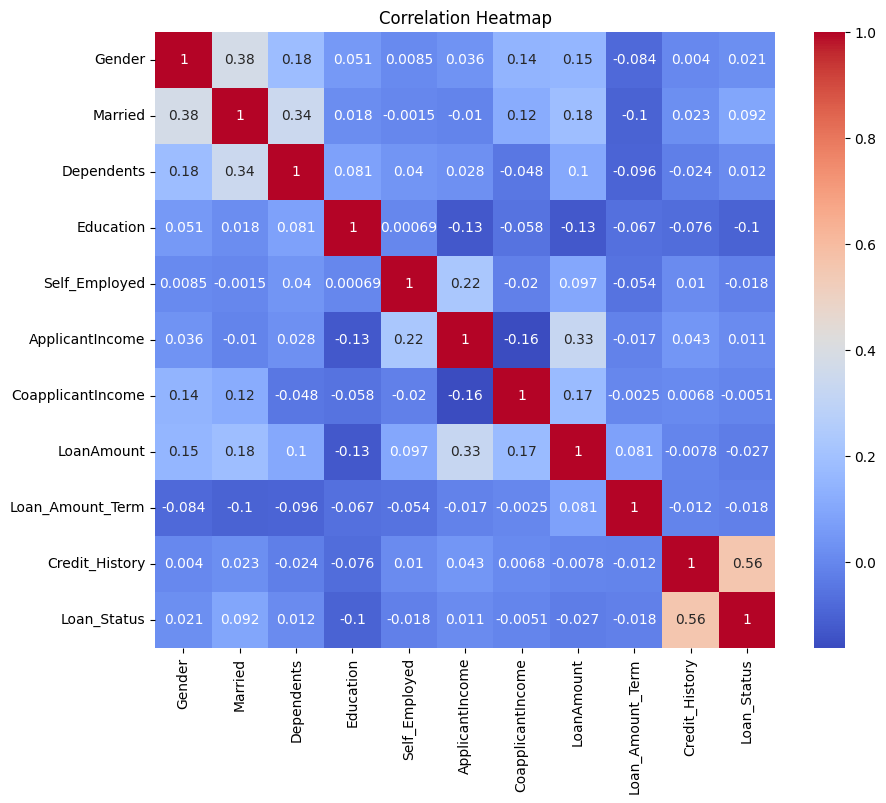

In [ ]:
#Correlation Matrix and Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Feature Engineering
df["TotalIncome"]=df["ApplicantIncome"]+df["CoapplicantIncome"]
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,Urban,1,5849.0
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0


In [ ]:
#Convert Data Types
print(df.dtypes)
df["Loan_Amount_Term"]=df["Loan_Amount_Term"].astype(int)
print(df.dtypes)

Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status            int64
TotalIncome          float64
dtype: object
Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term       int64
Credit_History       float64
Property_Area         object
Loan_Status            int64
TotalIncome          float64
dtype: object


In [ ]:
#Handle Inconsistent/Noisy Data
df.dropna(inplace=True)

df.reset_index(drop=True,inplace=True)

print(df.shape)

(573, 14)


In [ ]:
#Train-Test Split
X=df.drop(["Loan_ID","Loan_Status"],axis=1)

y=df["Loan_Status"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print(X_train.shape)
print(X_test.shape)

(458, 12)
(115, 12)


In [ ]:
#SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Apply one-hot encoding to Property_Area column in X_train and X_test
X_train = pd.get_dummies(X_train, columns=['Property_Area'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Property_Area'], drop_first=True)

smote=SMOTE(random_state=42)

X_train,y_train=smote.fit_resample(X_train,y_train)

print(y_train.value_counts())

Loan_Status
1    317
0    317
Name: count, dtype: int64


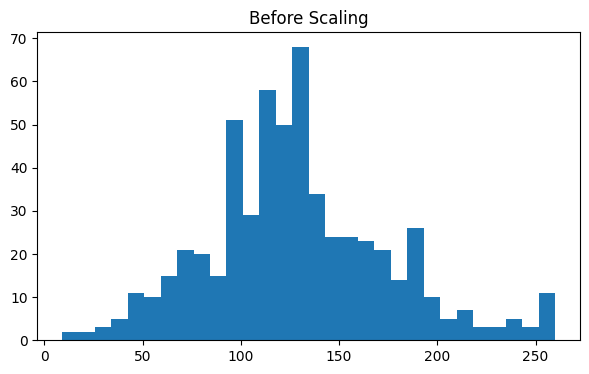

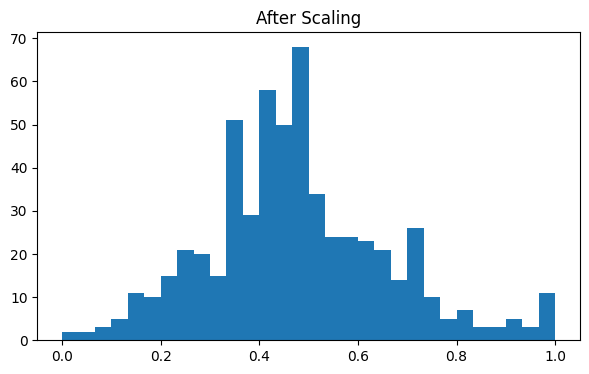

In [ ]:
#Distribution Before and After Scaling
#BEFORE
plt.figure(figsize=(7,4))

plt.hist(df["LoanAmount"],bins=30)

plt.title("Before Scaling")

plt.show()
#AFTER
scaled=MinMaxScaler()

loan_scaled=scaled.fit_transform(df[["LoanAmount"]])

plt.figure(figsize=(7,4))

plt.hist(loan_scaled,bins=30)

plt.title("After Scaling")

plt.show()

In [ ]:
#Compare Before and After
print("Original Dataset Shape")

print(pd.read_csv("train.csv").shape)

print()

print("Preprocessed Dataset Shape")

print(df.shape)

print()

print(df.head())

Original Dataset Shape
(614, 13)

Preprocessed Dataset Shape
(573, 14)

    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0               360   
1             4583             1508.0       128.0               360   
2             3000                0.0        66.0               360   
3             2583             2358.0       120.0               360   
4             6000                0.0       141.0               360   

   Credit_History Property_Area  Loan_Status  TotalIncome  
0             1.0   

In [ ]:
#Save Clean Dataset
df.to_csv("LoanPrediction_Cleaned.csv",
          index=False)

print("Dataset Saved Successfully")
#Download file
from google.colab import files

files.download("LoanPrediction_Cleaned.csv")

Dataset Saved Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The Loan Prediction dataset was successfully preprocessed. Missing values were handled using median and mode imputation. Duplicate records were removed. Outliers were detected using the IQR method and eliminated. Categorical variables were converted into numerical form using Label Encoding and One-Hot Encoding. Feature scaling was performed using Min-Max Normalization and Standardization. Feature engineering was carried out by creating a TotalIncome attribute. The dataset was split into training and testing sets, balanced using SMOTE, visualized before and after preprocessing, and finally saved as a cleaned CSV file.
